# Análisis y Predicción de Enfermedades Cardíacas

Este notebook realiza un análisis completo del dataset de enfermedades cardíacas, incluyendo:

1. Análisis Exploratorio de Datos (EDA)
2. Preprocesamiento y Feature Engineering
3. Modelado con Regresión Logística
4. Evaluación y Visualización de Resultados

## Descripción de Variables
- **age**: Edad del paciente
- **sex**: Sexo (1 = masculino, 0 = femenino)
- **cp**: Tipo de dolor en el pecho
- **trestbps**: Presión arterial en reposo
- **chol**: Colesterol sérico
- **fbs**: Azúcar en sangre en ayunas > 120 mg/dl
- **restecg**: Resultados electrocardiográficos en reposo
- **thalach**: Frecuencia cardíaca máxima alcanzada
- **exang**: Angina inducida por ejercicio
- **oldpeak**: Depresión ST inducida por ejercicio
- **slope**: Pendiente del segmento ST
- **ca**: Número de vasos principales
- **thal**: Resultado de la prueba de esfuerzo
- **condition**: Variable objetivo (1 = presencia de enfermedad, 0 = ausencia)

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
import joblib

# Configuración de visualización
%matplotlib inline
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
sns.set_palette('husl')

## 1. Carga y Exploración Inicial de Datos

In [2]:
# Cargar el dataset
df = pd.read_csv('../datasets/heart_cleveland_upload.csv')

# Mostrar información básica
print("Dimensiones del dataset:", df.shape)
print("\nPrimeras 5 filas:")
display(df.head())

print("\nEstadísticas descriptivas:")
display(df.describe())

print("\nInformación del dataset:")
display(df.info())

# Verificar valores faltantes
print("\nValores faltantes por columna:")
display(df.isnull().sum())

Dimensiones del dataset: (297, 14)

Primeras 5 filas:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0



Estadísticas descriptivas:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


None


Valores faltantes por columna:


age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64

## 2. Análisis Exploratorio de Datos (EDA)

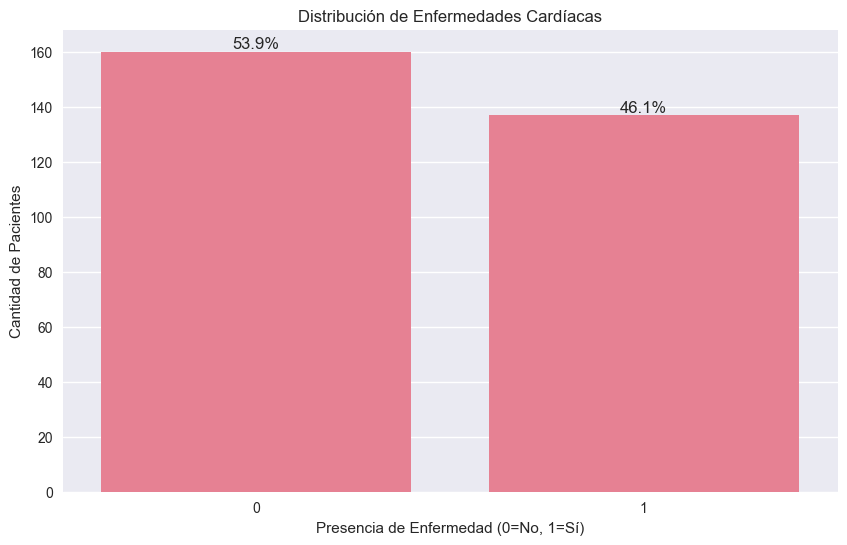

In [3]:
# 2.1 Distribución de la variable objetivo
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='condition')
plt.title('Distribución de Enfermedades Cardíacas')
plt.xlabel('Presencia de Enfermedad (0=No, 1=Sí)')
plt.ylabel('Cantidad de Pacientes')

# Agregar porcentajes
total = len(df)
for p in plt.gca().patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    plt.annotate(percentage, (p.get_x() + p.get_width()/2., p.get_height()),
                 ha='center', va='bottom')
plt.show()

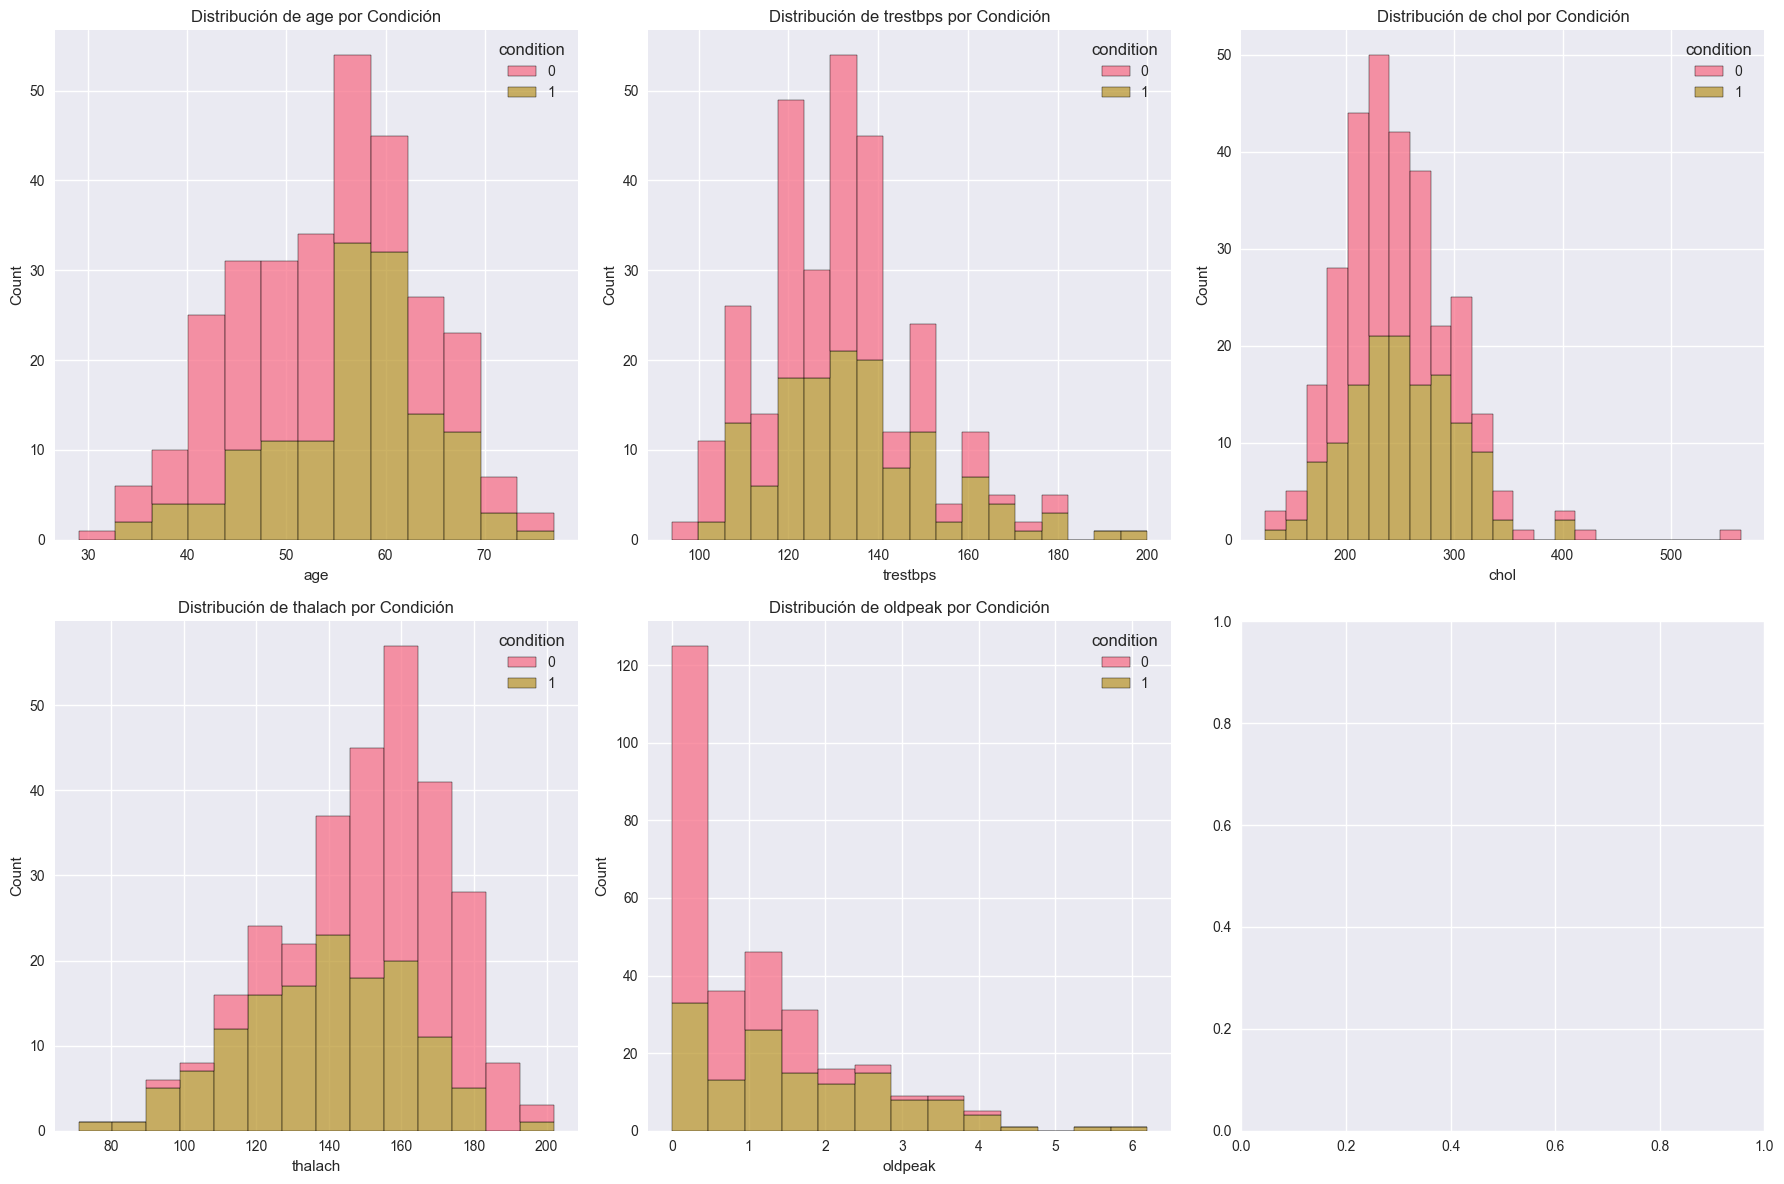

In [4]:
# 2.2 Distribución de variables numéricas
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, hue='condition', multiple="stack", ax=axes[idx])
    axes[idx].set_title(f'Distribución de {col} por Condición')

plt.tight_layout()
plt.show()

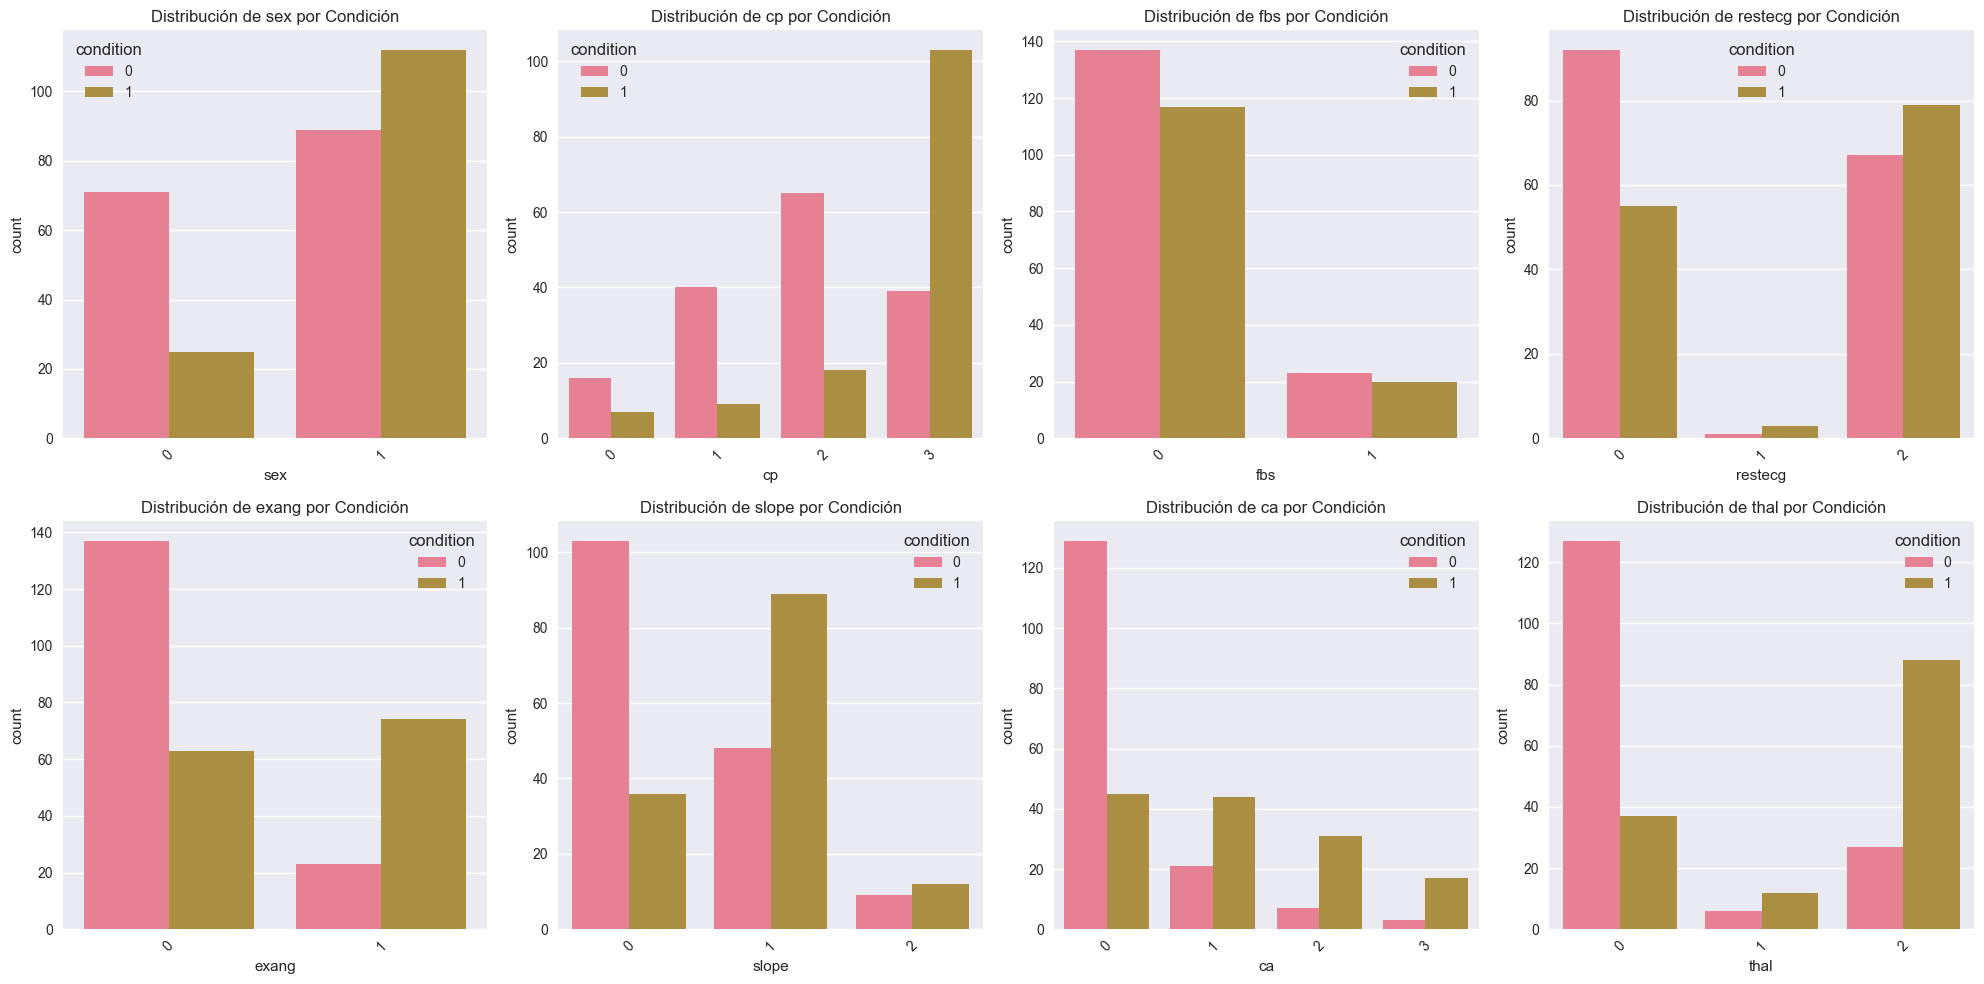

In [5]:
# 2.3 Análisis de variables categóricas
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, hue='condition', ax=axes[idx])
    axes[idx].set_title(f'Distribución de {col} por Condición')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

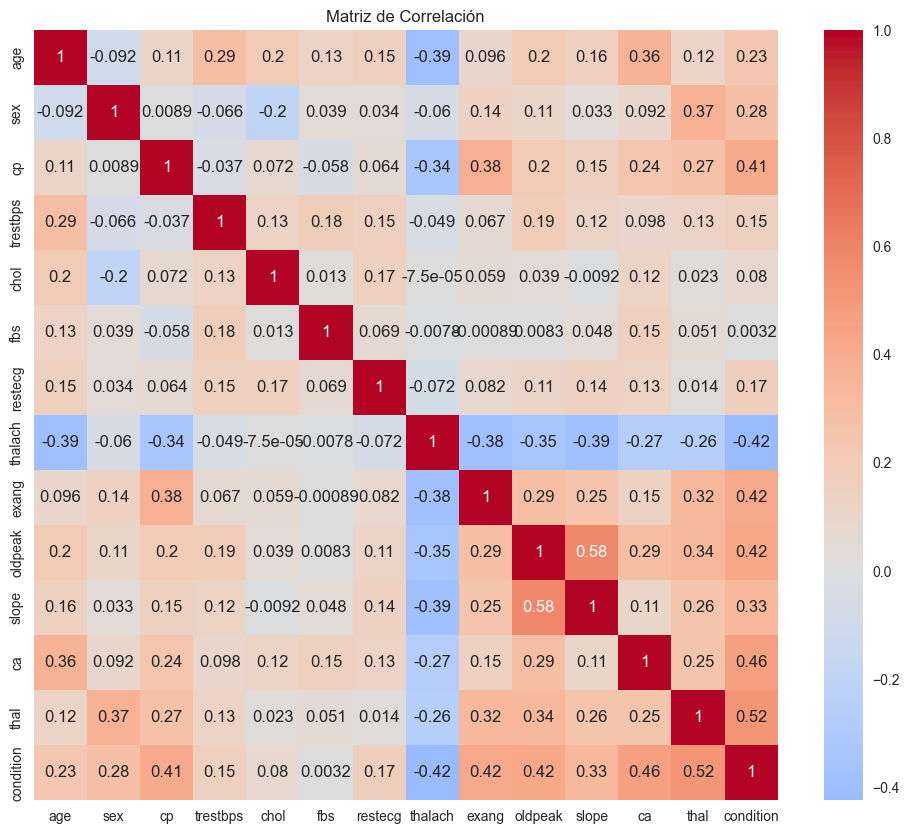

In [6]:
# 2.4 Matriz de correlación
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()

## 3. Preparación de Datos para el Modelado

In [7]:
# Separar features y target
X = df.drop('condition', axis=1)
y = df['condition']

# Escalar características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split de datos
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Dimensiones de los conjuntos de datos:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

Dimensiones de los conjuntos de datos:
X_train: (237, 13)
X_test: (60, 13)
y_train: (237,)
y_test: (60,)


## 4. Entrenamiento y Evaluación del Modelo

In [8]:
# Entrenar modelo
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

# Validación cruzada
cv_scores = cross_val_score(model, X_train, y_train, cv=5)
print("Resultados de validación cruzada:")
print(f"Accuracy promedio: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Predicciones
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Reporte de clasificación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Resultados de validación cruzada:
Accuracy promedio: 0.8520 (+/- 0.0733)

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.77      0.72      0.74        32
           1       0.70      0.75      0.72        28

    accuracy                           0.73        60
   macro avg       0.73      0.73      0.73        60
weighted avg       0.74      0.73      0.73        60



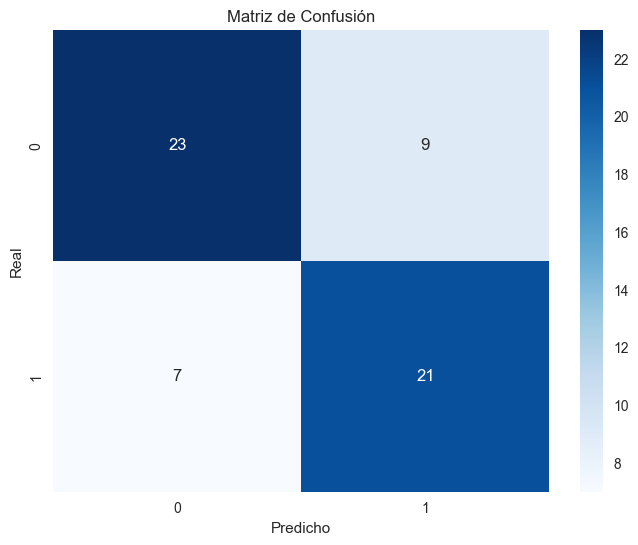

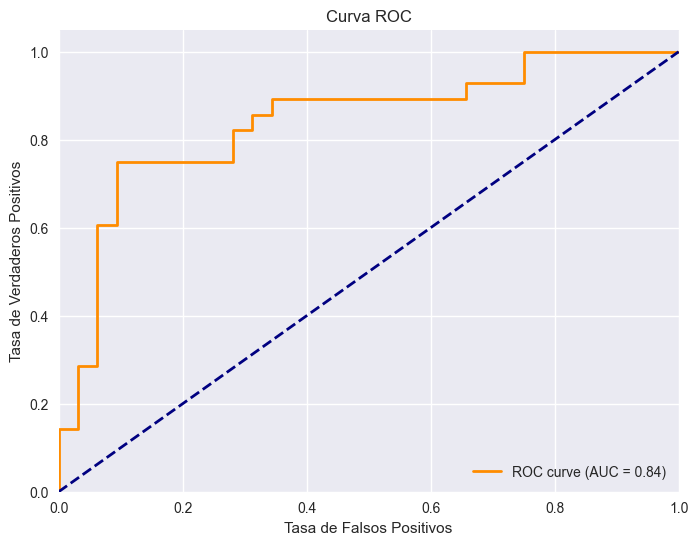

In [9]:
# Matriz de confusión
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

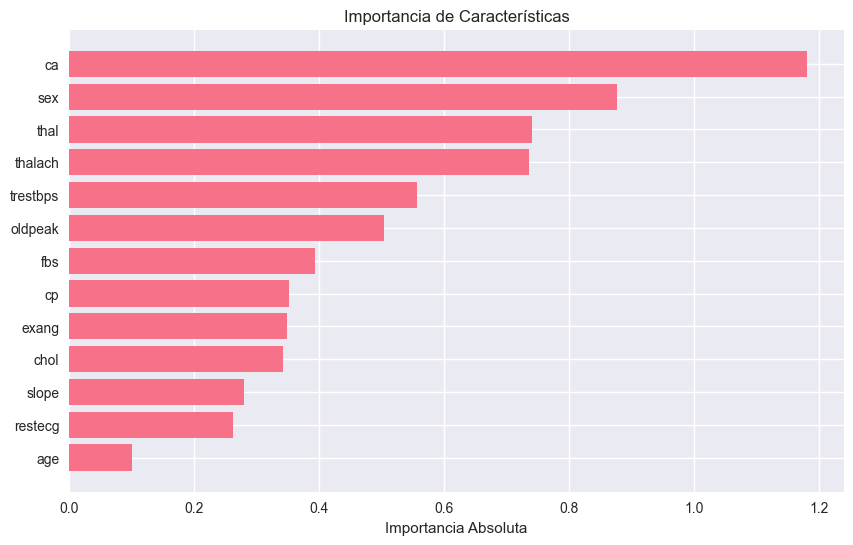

In [10]:
# Importancia de características
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': abs(model.coef_[0])
})
feature_importance = feature_importance.sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.title('Importancia de Características')
plt.xlabel('Importancia Absoluta')
plt.show()

## 5. Guardar el Modelo

In [11]:
# Guardar modelo y scaler
joblib.dump(model, 'heart_disease_model.joblib')
joblib.dump(scaler, 'heart_disease_scaler.joblib')
print("Modelo y scaler guardados exitosamente!")

Modelo y scaler guardados exitosamente!


## 6. Ejemplo de Predicción

In [12]:
# Crear un caso de ejemplo
ejemplo = pd.DataFrame([
    {
        'age': 55,
        'sex': 1,
        'cp': 0,
        'trestbps': 140,
        'chol': 240,
        'fbs': 0,
        'restecg': 0,
        'thalach': 150,
        'exang': 0,
        'oldpeak': 1.5,
        'slope': 1,
        'ca': 0,
        'thal': 2
    }
])

# Escalar el ejemplo
ejemplo_scaled = scaler.transform(ejemplo)

# Realizar predicción
pred = model.predict(ejemplo_scaled)
pred_proba = model.predict_proba(ejemplo_scaled)

print("Predicción para el caso de ejemplo:")
print(f"Resultado: {'Presencia' if pred[0] == 1 else 'Ausencia'} de enfermedad cardíaca")
print(f"Probabilidad de enfermedad cardíaca: {pred_proba[0][1]:.2%}")

Predicción para el caso de ejemplo:
Resultado: Presencia de enfermedad cardíaca
Probabilidad de enfermedad cardíaca: 52.99%
